### Get list of CP pairs from CPDB and their tm align scores

In [1]:
import numpy as np
import pandas as pd

fp = '/home/ubuntu/plmCP/CPDB/tm_scores_cpdb.txt'

df = pd.read_csv(fp, sep=' ')

all_names_cpdb = pd.concat([df['Protein1'], df['Protein2']])

all_names_cpdb_unique = all_names_cpdb.unique()
print(f'Sample of unique cpdb domains: {all_names_cpdb_unique[0:5]}, total: {len(all_names_cpdb_unique)}')

Sample of unique cpdb domains: ['1fp3A' '1nc5A' '1v5cA' '1vd5A' '1wzzA'], total: 2238


In [23]:
len(all_names_cpdb_unique)

2238

### Filter for real CPs following TM score criteria

In [8]:
df_tm_cp_above05 = df[df['tmscore-CP'] > 0.5]

df_tm_cp_above05_diff_greater_than_0 = df_tm_cp_above05[(df_tm_cp_above05['tmscore-CP']-df_tm_cp_above05['tmscore']) > 0]

print(f'After filtering based on TM CP difference {len(df_tm_cp_above05_diff_greater_than_0)}')
all_names = pd.concat([df_tm_cp_above05_diff_greater_than_0['Protein1'], df_tm_cp_above05_diff_greater_than_0['Protein2']])
all_names_unique = all_names.unique()
print(f'Total unique: {len(all_names_unique)}')

After filtering based on TM CP difference 3181
Total unique: 1667


In [14]:
df_tm_cp_above05_diff_greater_than_0

,Protein1,Protein2,tmscore,tmscore-CP
1,1fp3A,1wu4A,0.67768,0.67887
2,1fp3A,2drqA,0.67558,0.67691
3,1fp3A,1wu6A,0.67434,0.67558
4,1fp3A,1hzfA,0.54695,0.55763
5,1fp3A,1ks8A,0.63233,0.69125
...,...,...,...,...
4164,1xe4A,2hv2A,0.47581,0.59132
4165,1xe4A,2i00A,0.45702,0.58056
4166,1xf8A,2hv2A,0.47354,0.59084
4167,1xf8A,2i00A,0.45886,0.58051


In [16]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

/tmp/ipykernel_2911259/2852767692.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_tm_cp_above05_diff_greater_than_0['difference'] = df_tm_cp_above05_diff_greater_than_0['tmscore-CP'] - df_tm_cp_above05_diff_greater_than_0['tmscore']


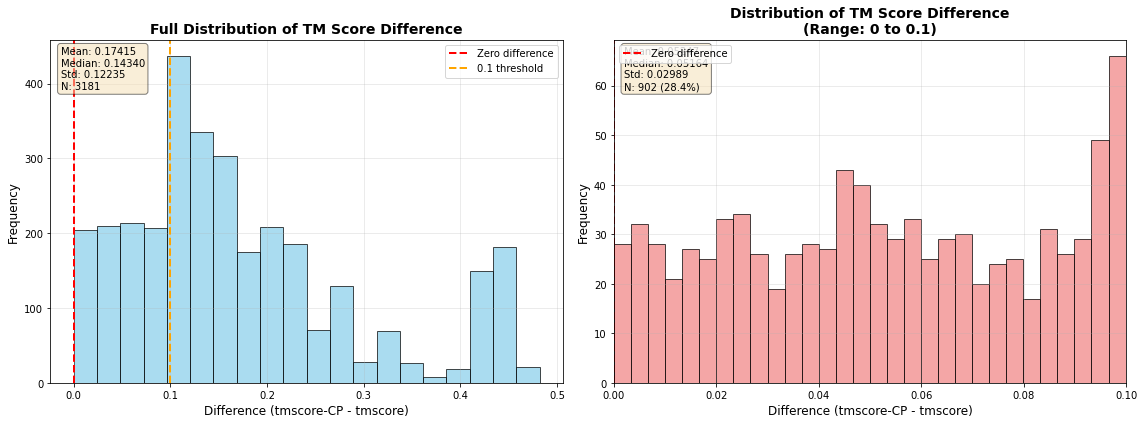

In [19]:
# Calculate the difference
df_tm_cp_above05_diff_greater_than_0['difference'] = df_tm_cp_above05_diff_greater_than_0['tmscore-CP'] - df_tm_cp_above05_diff_greater_than_0['tmscore']

# Filter data for differences between 0 and 0.1
df_filtered = df_tm_cp_above05_diff_greater_than_0[(df_tm_cp_above05_diff_greater_than_0['difference'] >= 0) & (df_tm_cp_above05_diff_greater_than_0['difference'] <= 0.1)]

# Create two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Full distribution
ax1.hist(df_tm_cp_above05_diff_greater_than_0['difference'], bins=20, edgecolor='black', alpha=0.7, color='skyblue')
ax1.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero difference')
ax1.axvline(x=0.1, color='orange', linestyle='--', linewidth=2, label='0.1 threshold')
ax1.set_xlabel('Difference (tmscore-CP - tmscore)', fontsize=12)
ax1.set_ylabel('Frequency', fontsize=12)
ax1.set_title('Full Distribution of TM Score Difference', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Add statistics for full distribution
mean_diff = df_tm_cp_above05_diff_greater_than_0['difference'].mean()
median_diff = df_tm_cp_above05_diff_greater_than_0['difference'].median()
std_diff = df_tm_cp_above05_diff_greater_than_0['difference'].std()
textstr1 = f'Mean: {mean_diff:.5f}\nMedian: {median_diff:.5f}\nStd: {std_diff:.5f}\nN: {len(df_tm_cp_above05_diff_greater_than_0)}'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
ax1.text(0.02, 0.98, textstr1, transform=ax1.transAxes, fontsize=10,
        verticalalignment='top', bbox=props)

# Plot 2: Filtered distribution (0 to 0.1)
ax2.hist(df_filtered['difference'], bins=30, edgecolor='black', alpha=0.7, color='lightcoral')
ax2.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero difference')
ax2.set_xlabel('Difference (tmscore-CP - tmscore)', fontsize=12)
ax2.set_ylabel('Frequency', fontsize=12)
ax2.set_title('Distribution of TM Score Difference\n(Range: 0 to 0.1)', fontsize=14, fontweight='bold')
ax2.set_xlim(0, 0.1)
ax2.legend()
ax2.grid(True, alpha=0.3)

# Add statistics for filtered distribution
mean_filt = df_filtered['difference'].mean()
median_filt = df_filtered['difference'].median()
std_filt = df_filtered['difference'].std()
pct_in_range = (len(df_filtered) / len(df_tm_cp_above05_diff_greater_than_0)) * 100
textstr2 = f'Mean: {mean_filt:.5f}\nMedian: {median_filt:.5f}\nStd: {std_filt:.5f}\nN: {len(df_filtered)} ({pct_in_range:.1f}%)'
ax2.text(0.02, 0.98, textstr2, transform=ax2.transAxes, fontsize=10,
        verticalalignment='top', bbox=props)

plt.tight_layout()
plt.show()

In [24]:
def get_pdbs(list_of_pdbs):
    failed = []
    for x, pdb in enumerate(list_of_pdbs):
        pdb_code = pdb[:4].upper()
        final_filename = f'{pdb_code}_{pdb[4]}.pdb'
        
        # Check if the final processed file already exists
        if os.path.exists(final_filename):
            print(f'{final_filename} already exists, skipping...')
            if x % 100 == 0:
                print(f'Processed {x} structures')
            continue
        
        print(f'Attempting to download {pdb_code}')
        if pdb_code:
            url = f"https://files.rcsb.org/download/{pdb_code}.pdb"
            filename = f"{pdb_code}.pdb"
            print(f"Downloading {pdb_code}.pdb from {url}...")
            os.system(f"wget -qnc {url} -O {filename}")
    
            os.system(f'pdb_selchain -{pdb[4]} {filename} | pdb_delhetatm | pdb_head -1000000 > {final_filename}')
            os.system(f'rm {filename}')
            if not os.path.exists(final_filename):
                print(f"Failed to download {final_filename}")
                failed.append(pdb_code)
        else:
            print(f"Failed to download {pdb_code}")
            failed.append(pdb_code)
            
        if x % 100 == 0:
            print(f'Processed {x} structures')
    return failed

In [17]:
# def get_pdbs(list_of_pdbs):
#     failed = []
#     for x,pdb in enumerate(list_of_pdbs):
#         pdb_code = pdb[:4].upper()
#         print(f'Attempting to download {pdb_code}')
#         if pdb_code:
#             url = f"https://files.rcsb.org/download/{pdb_code}.pdb"
#             filename = f"{pdb_code}.pdb"
#             print(f"Downloading {pdb_code}.pdb from {url}...")
#             os.system(f"wget -qnc {url} -O {filename}")
    
#             os.system(f'pdb_selchain -{pdb[4]} {filename} | pdb_delhetatm | pdb_head -1000000 > {pdb_code}_{pdb[4]}.pdb')
#             os.system(f'rm {filename}')
#             if not os.path.exists(f'{pdb_code}_{pdb[4]}.pdb'):
#                 print(f"Failed to download {pdb_code}_{pdb[4]}.pdb")
#                 failed.append(pdb_code)
#         else:
#             print(f"Failed to download {pdb_code}")
#             failed.append(pdb_code)
            
#         if x % 100 == 0:
#             print(f'Processed {x} structures')
#     return failed

In [25]:
len(all_names_cpdb_unique)

2238

In [27]:
pdbs_cpdb

['1fp3A',
 '1nc5A',
 '1v5cA',
 '1vd5A',
 '1wzzA',
 '2ahfA',
 '2gh4A',
 '2sqcA',
 '1a22A',
 '1a7dA',
 '1a7mA',
 '1aewA',
 '1aluA',
 '1au1A',
 '1ax8A',
 '1axiA',
 '1b5lA',
 '1bbhA',
 '1bcfA',
 '1bg7A',
 '1bgcA',
 '1bgdA',
 '1buyA',
 '1cd9A',
 '1cnt1',
 '1csmA',
 '1ddnA',
 '1dpsA',
 '1ea8A',
 '1eerA',
 '1emrA',
 '1eumA',
 '1evsA',
 '1f1mA',
 '1f30A',
 '1f6fA',
 '1fhaA',
 '1fxkA',
 '1fxkC',
 '1gncA',
 '1gwgA',
 '1h96A',
 '1huwA',
 '1hwgA',
 '1i1rB',
 '1il6A',
 '1jgcA',
 '1ji5A',
 '1jmwA',
 '1jreA',
 '1k33A',
 '1k40A',
 '1l3pA',
 '1lihA',
 '1lkiA',
 '1m62A',
 '1mfrA',
 '1nf4A',
 '1nz6A',
 '1nzeA',
 '1o9rA',
 '1oryA',
 '1p68A',
 '1p9mB',
 '1pvhB',
 '1qghA',
 '1qq3A',
 '1r03A',
 '1rccA',
 '1rcdA',
 '1rciA',
 '1rhgA',
 '1s3qA',
 '1sofA',
 '1umnA',
 '1uvhA',
 '1v74B',
 '1vlgA',
 '1vlsA',
 '1wozA',
 '1wu3I',
 '1wvtA',
 '1yjgA',
 '1z4aA',
 '1z6oM',
 '1z7cA',
 '1zujA',
 '1zwiC',
 '1zzpA',
 '2asrA',
 '2atkC',
 '2b0hA',
 '2bjyA',
 '2bk6A',
 '2bkcA',
 '2c2fA',
 '2c41A',
 '2cf7A',
 '2chiA',
 '2clbA',


In [26]:
import os
pdbs_cpdb=list(all_names_cpdb_unique)
get_pdbs(pdbs_cpdb)

1FP3_A.pdb already exists, skipping...
Processed 0 structures
1NC5_A.pdb already exists, skipping...
1V5C_A.pdb already exists, skipping...
1VD5_A.pdb already exists, skipping...
1WZZ_A.pdb already exists, skipping...
2AHF_A.pdb already exists, skipping...
2GH4_A.pdb already exists, skipping...
Attempting to download 2SQC
1A22_A.pdb already exists, skipping...
1A7D_A.pdb already exists, skipping...
1A7M_A.pdb already exists, skipping...
1AEW_A.pdb already exists, skipping...
1ALU_A.pdb already exists, skipping...
1AU1_A.pdb already exists, skipping...
1AX8_A.pdb already exists, skipping...
1AXI_A.pdb already exists, skipping...
1B5L_A.pdb already exists, skipping...
1BBH_A.pdb already exists, skipping...
1BCF_A.pdb already exists, skipping...
1BG7_A.pdb already exists, skipping...
1BGC_A.pdb already exists, skipping...
1BGD_A.pdb already exists, skipping...
1BUY_A.pdb already exists, skipping...
1CD9_A.pdb already exists, skipping...
1CNT_1.pdb already exists, skipping...
1CSM_A.pdb al

[]

In [13]:
import os
pdbs_cpdb=list(all_names_unique)
get_pdbs(pdbs_cpdb)

Attempting to download 1FP3
Processed 0 structures
Attempting to download 1NC5
Attempting to download 1V5C
Attempting to download 1VD5
Attempting to download 1WZZ
Attempting to download 2AHF
Attempting to download 2GH4
Attempting to download 1A22
Attempting to download 1A7D
Attempting to download 1A7M
Attempting to download 1AEW
Attempting to download 1ALU
Attempting to download 1AU1
Attempting to download 1AX8
Attempting to download 1AXI
Attempting to download 1B5L
Attempting to download 1BBH
Attempting to download 1BCF
Attempting to download 1BG7
Attempting to download 1BGC
Attempting to download 1BGD
Attempting to download 1BUY
Attempting to download 1CD9
Attempting to download 1CNT
Attempting to download 1CSM
Attempting to download 1DDN
Attempting to download 1DPS
Attempting to download 1EA8
Attempting to download 1EER
Attempting to download 1EMR
Attempting to download 1EUM
Attempting to download 1EVS
Attempting to download 1F1M
Attempting to download 1F30
Attempting to download 1F

[]